# Section 1: Email security

Compare TF-IDF + Logistic Regression with an LSTM using the SpamAssassin corpus. The labels are **ham and spam**, not legitimate and phishing emails, so the results should be described as spam detection.

This revision removes ambiguous/duplicate normalized messages, applies security-aware stopword handling and stemming, records provenance, and selects alert thresholds on validation data. Outputs were cleared because earlier results do not belong to this revised pipeline; rerun from a fresh kernel, top to bottom.

## Setup

The working directory changes only in Colab. Local runs locate the repository root automatically. The installation cell states the required libraries; the run summary records the versions actually used.

In [8]:
import os
import sys

# Colab keeps files under /content; local kernels keep their current directory.
if "google.colab" in sys.modules:
    os.chdir("/content")

In [9]:
%pip install -q joblib matplotlib nltk numpy pandas scikit-learn torch

In [10]:
import hashlib
import importlib.metadata
import json
import os
import platform
import random
import re
import shutil
import sys
import tarfile
import urllib.request
from collections import Counter
from datetime import datetime, timezone
from email import policy
from email.parser import BytesParser
from html.parser import HTMLParser
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from nltk.stem import SnowballStemmer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, average_precision_score,
    classification_report, confusion_matrix, f1_score,
    precision_recall_curve, precision_score, recall_score,
    roc_auc_score, roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from torch import nn
from torch.utils.data import DataLoader, Dataset

### Experiment settings

Keep the seed, split sizes and epoch count together. Fixed seeds help repeatability, but different Python or package versions can still produce different results. Colab writes to its own workspace, not directly to the local repository.

In [11]:
# Using the same seed for data splitting, vocabulary construction, and model training.
# This improves repeatability, although results can still vary across environments.
seed = 42

# Allocating 15% of emails for final testing and 15% for validation.
# Remaining 70% is used for training.
test_size = 0.15
val_size = 0.15

# Training the LSTM for a fixed epoch budget.
# messages to be incorrectly flagged as spam.
epochs = 6
false_alert_budget = 0.01

# Helpers to manage the project directories
def find_project_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "notebooks").is_dir() and (candidate / "docs").is_dir():
            return candidate
    return Path.cwd()

# Keep the data, saved models and results in the same experiment folder.
in_colab = "google.colab" in sys.modules
root = Path("/content/section_01_workspace") if in_colab else find_project_root()
data_dir = root / "data/raw/spamassassin"
processed_dir = root / "data/processed/section_01"
model_dir = root / "models/section_01"
results_dir = root / "reports/section_01"

for directory in (data_dir, processed_dir, model_dir, results_dir / "metrics", results_dir / "figures"):
    directory.mkdir(parents=True, exist_ok=True)

# Using the same seed to initialising the following.
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

## Load the emails

Download the easy-ham and spam archives from Apache, reusing local copies when available. Only use these trusted archives with this extraction step; the download is not checksum-verified.

In [12]:
# Base URL of the Public SpamAssassin email dataset
base_url = "https://spamassassin.apache.org/old/publiccorpus"

# Mapping each file name to relavent extraction folder and class sources
archives = {
    "20030228_easy_ham.tar.bz2": "easy_ham",
    "20030228_spam.tar.bz2": "spam",
}

# Downloading and unpacking the archive only if the email folder is missing.
for archive_name, folder_name in archives.items():
    archive_path = data_dir / archive_name
    if not (data_dir / folder_name).exists():

        # Downloading the archive only if it is missing.
        if not archive_path.exists():
            urllib.request.urlretrieve(f"{base_url}/{archive_name}", archive_path)
       
        #extracting the archive to the relevant folder.    
        with tarfile.open(archive_path, "r:bz2") as archive:
            archive.extractall(data_dir)

#saving the archive hash of each downloaded archive for verification.
dataset_hashes = {
    name: hashlib.sha256((data_dir / name).read_bytes()).hexdigest()
    for name in archives if (data_dir / name).exists()
}

### Read and normalize the messages

Prefer the plain-text MIME alternative and fall back to HTML only when plain text is unavailable. Attachments are excluded, HTML is parsed with the standard-library parser, and malformed charset events are counted. Normalization preserves URL/address markers and negation, removes generic English stopwords for TF-IDF, and stems tokens for both model branches.

In [13]:
# Defiining patterns for whitespace, URLSs, Email addresses and words.
whitespace = re.compile(r"\s+")
url_pattern = re.compile(r"(?:https?://|www\.)\S+", re.I)
email_pattern = re.compile(r"\b[\w.+-]+@[\w.-]+\.[A-Za-z]{2,}\b")
token_pattern = re.compile(r"\w+", re.UNICODE)
stemmer = SnowballStemmer("english")

# Defining a set of stopwords that should not be removed during text processing.
protected_stopwords = {"no", "not", "nor"}
tfidf_stop_words = sorted(
    {stemmer.stem(word) for word in ENGLISH_STOP_WORDS if word not in protected_stopwords}
)

# Tracking malformed emails and other email parsing issues.
parsing_stats = Counter()

# Extracting text from HTML emails using the HTMLParser class.
class HTMLTextExtractor(HTMLParser):
    def __init__(self):
        super().__init__()
        self.fragments = []

    def handle_data(self, data):
        self.fragments.append(data)

def html_to_text(value):
    parser = HTMLTextExtractor()
    parser.feed(value)
    return " ".join(parser.fragments)

# Decoding email parts, handling character sets, and counting replacement characters.
def decode_part(part):
    payload = part.get_payload(decode=True)
    if not isinstance(payload, bytes):
        return str(part.get_payload())
    charset = part.get_content_charset() or "utf-8"
    try:
        decoded = payload.decode(charset, errors="replace")
    except LookupError:
        parsing_stats["unknown_charset_fallbacks"] += 1
        decoded = payload.decode("utf-8", errors="replace")
    parsing_stats["replacement_characters"] += decoded.count("�")
    return decoded

# Reading and parsing email files, extracting the subject and body, and normalizing whitespace.
def read_email(path):
    message = BytesParser(policy=policy.default).parsebytes(path.read_bytes())
    candidates = [
        part for part in message.walk()
        if part.get_content_disposition() != "attachment"
        and part.get_content_type() in {"text/plain", "text/html"}
    ]
    chosen = next((part for part in candidates if part.get_content_type() == "text/plain"), None)
    if chosen is None:
        chosen = next((part for part in candidates if part.get_content_type() == "text/html"), None)
        if chosen is not None:
            parsing_stats["html_fallback_messages"] += 1
    body = decode_part(chosen) if chosen is not None else ""
    if chosen is None:
        parsing_stats["messages_without_text_body"] += 1
    elif chosen.get_content_type() == "text/html":
        body = html_to_text(body)
    text = f"Subject: {message.get('subject') or ''} Body: {body}"
    return whitespace.sub(" ", text).strip()

# Normalizing text by replacing URLs and email addresses with markers, converting to lowercase, and stemming words.
def normalize(text):
    text = url_pattern.sub(" urltoken ", text.lower())
    text = email_pattern.sub(" emailtoken ", text)
    return " ".join(stemmer.stem(token) for token in token_pattern.findall(text))

,messages
class,
ham,2471
spam,476


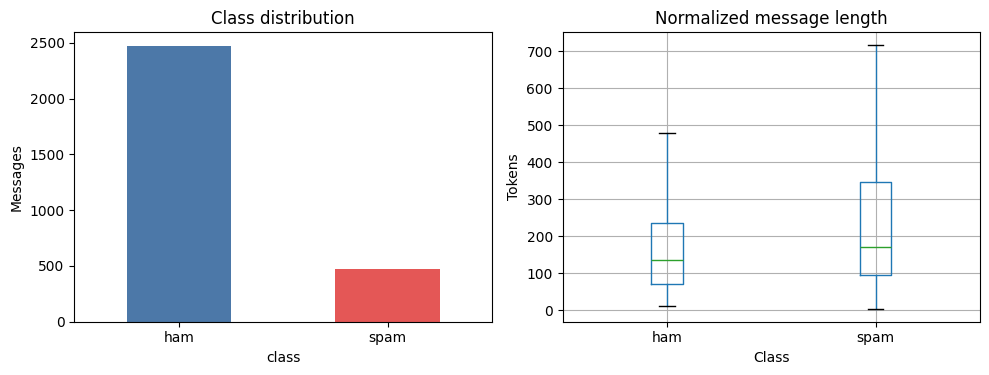

In [14]:
# Read every email and record its path. ham is 0 and spam is 1.
records = []
for folder, label in (("easy_ham", 0), ("spam", 1)):
    for path in sorted((data_dir / folder).rglob("*")):
        if path.is_file() and path.name.lower() != "cmds":
            records.append({
                "path": str(path), "text": read_email(path), "label": label,
                "source_sha256": hashlib.sha256(path.read_bytes()).hexdigest(),
            })

# Convert the collected email records into a table and normalize the text.
messages = pd.DataFrame(records)
messages["normalized_text"] = messages["text"].map(normalize)

# Identifying empty messages and texts with conflicting labels.
empty_normalized = messages["normalized_text"].eq("")
exact_conflicts = messages.groupby("text")["label"].nunique()
exact_conflict_text = exact_conflicts[exact_conflicts > 1].index
normalized_conflicts = messages.groupby("normalized_text")["label"].nunique()
normalized_conflict_text = normalized_conflicts[normalized_conflicts > 1].index

# Removing empty , conflictiing, and duplicated messages used by both models.
emails = messages.loc[
    ~empty_normalized
    & ~messages["text"].isin(exact_conflict_text)
    & ~messages["normalized_text"].isin(normalized_conflict_text)
].drop_duplicates("normalized_text").reset_index(drop=True)

#Creating hashes for tracing the original and normalized message content.

emails["sha256"] = emails["text"].map(lambda text: hashlib.sha256(text.encode()).hexdigest())
emails["normalized_sha256"] = emails["normalized_text"].map(
    lambda text: hashlib.sha256(text.encode()).hexdigest()
)
dataset_hashes["extracted_corpus_manifest"] = hashlib.sha256(
    "".join(sorted(messages["source_sha256"])).encode()
).hexdigest()

# Creating readable class names and message length statistics for analysis and visualization.
emails["class"] = emails["label"].map({0: "ham", 1: "spam"})
emails["raw_characters"] = emails["text"].str.len()
emails["normalized_tokens"] = emails["normalized_text"].str.split().str.len()

# Saving a summary of parsing and cleaning, and duplication results to a JSON file for reference.
text_profile = {
    "source_messages": len(messages),
    "exact_conflicting_texts_excluded": len(exact_conflict_text),
    "normalized_conflicting_texts_excluded": len(normalized_conflict_text),
    "empty_normalized_messages_excluded": int(empty_normalized.sum()),
    "records_after_normalized_deduplication": len(emails),
    **parsing_stats,
}
(processed_dir / "text-profile.json").write_text(json.dumps(text_profile, indent=2))

# Displaying the class counts,class distribution and normalized message length.
class_counts = emails["class"].value_counts().reindex(["ham", "spam"])
display(class_counts.rename("messages").to_frame())
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
class_counts.plot.bar(color=["#4C78A8", "#E45756"], rot=0, ylabel="Messages", title="Class distribution", ax=axes[0])
emails.boxplot(column="normalized_tokens", by="class", showfliers=False, ax=axes[1])
axes[1].set(title="Normalized message length", xlabel="Class", ylabel="Tokens")
fig.suptitle("")
fig.tight_layout()
fig.savefig(results_dir / "figures/data-exploration.png", dpi=180)
plt.show()

## Split the data

Use the same stratified 70/15/15 split for both models. Ambiguous and duplicate **normalized** representations were removed before splitting, preventing exact model-input overlap. Save raw and normalized hashes so membership can be traced later.

In [15]:
# Splitting off 15% of the emails for final testing.
train_val, test = train_test_split(
    emails, test_size=test_size, stratify=emails["label"], random_state=seed,
)

# Splitting the remaining emails into training and validation sets. 
# Overall 70% emails are used for training, 15% for validation and 15% for testing.
train, val = train_test_split(
    train_val,
    test_size=val_size / (1 - test_size),
    stratify=train_val["label"],
    random_state=seed,
)

# Resetting row indexes to ensure a clean DataFrame structure.
train, val, test = [frame.reset_index(drop=True) for frame in (train, val, test)]

# recording the split information in a manifest file for reference and analysis.
manifest = pd.concat([
    frame[["path", "label", "source_sha256", "sha256", "normalized_sha256"]].assign(split=name)
    for name, frame in (("train", train), ("validation", val), ("test", test))
], ignore_index=True)

# Saving the manifest to a CSV file for future reference.
manifest.to_csv(processed_dir / "split_manifest.csv", index=False)
display(pd.crosstab(manifest["split"], manifest["label"]).rename(columns={0: "ham", 1: "spam"}))

label,ham,spam
split,,
test,371,72
train,1729,333
validation,371,71


## Verify text preprocessing

Review the branch-specific policy explicitly: both branches receive stemmed tokens; the TF-IDF branch removes a generic English list except negation words, while the LSTM keeps stopwords because word order and negation context may be informative. The checks below verify that no normalized representation crosses partitions.

In [16]:
# Collecting the normalized message hashes in each dataset partition.
split_hashes = {
    name: set(frame["normalized_sha256"])
    for name, frame in (("train", train), ("validation", val), ("test", test))
}

# Checking for any identical messages accross multiple dataset partitions.
overlap_report = {
    "train_validation": len(split_hashes["train"] & split_hashes["validation"]),
    "train_test": len(split_hashes["train"] & split_hashes["test"]),
    "validation_test": len(split_hashes["validation"] & split_hashes["test"]),
    "tfidf_stopword_count": len(tfidf_stop_words),
    "protected_negation_terms": sorted(protected_stopwords),
}

# Saving the overlap report to a JSON file for reference and analysis.
(processed_dir / "representation-overlap.json").write_text(json.dumps(overlap_report, indent=2))
display(pd.Series({**text_profile, **overlap_report}).to_frame("value"))

,value
source_messages,3000
exact_conflicting_texts_excluded,0
normalized_conflicting_texts_excluded,0
empty_normalized_messages_excluded,0
records_after_normalized_deduplication,2947
replacement_characters,3701
html_fallback_messages,211
unknown_charset_fallbacks,3
messages_without_text_body,1
train_validation,0


### Evaluation

Choose each model's threshold on validation data under a 1% false-positive-rate budget, then lock it before testing. Save the threshold with precision, recall, F1, confusion counts, ROC and precision-recall results.

In [17]:
# Selecting a decision threshold using the validation set to ensure that the false positive rate does not exceed the specified budget.
def select_threshold(labels, scores, max_fpr=false_alert_budget):

    # Testing evry unique score as a potential threshold.
    # Infinity reppresents the option of predicting no messsages as spam.
    labels, scores = np.asarray(labels), np.asarray(scores)
    thresholds = np.r_[np.inf, np.unique(scores)[::-1]]
    candidates = []
    for threshold in thresholds:

        # Calculating the false positive rate for this threshold.
        preds = scores >= threshold
        tn, fp, fn, tp = confusion_matrix(labels, preds, labels=[0, 1]).ravel()
        fpr = fp / max(fp + tn, 1)

        # Keep thresholds that satisfy the permitted false-alert rate.
        if fpr <= max_fpr:
            candidates.append((f1_score(labels, preds, zero_division=0), -fpr, threshold))

    #Choosing the threshold that maximizes the F1 score while satisfying a lower false positive rate.
    return max(candidates)[2]

# Evaluating one model using the selected threhold selected from validation data.
def show_results(name, labels, scores, threshold, filename):
    
    # Converting the contionus models scores into ham or spam predictions.
    preds = (scores >= threshold).astype(int)
    metrics = {
        "threshold": float(threshold),
        "validation_false_alert_budget": false_alert_budget,
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "roc_auc": roc_auc_score(labels, scores),
        "average_precision": average_precision_score(labels, scores),
        "confusion_matrix": confusion_matrix(labels, preds).tolist(),
        "classification_report": classification_report(
            labels, preds, target_names=["ham", "spam"], output_dict=True, zero_division=0,
        ),
    }

    # Saving the results as a JSON file for future reference.
    (results_dir / "metrics" / f"{filename}.json").write_text(json.dumps(metrics, indent=2))


    # Create the confusion matrix, ROC curve, and precision recall curve.
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    ConfusionMatrixDisplay.from_predictions(
        labels, preds, display_labels=["ham", "spam"], cmap="Blues", colorbar=False, ax=axes[0],
    )
    axes[0].set_title("Confusion matrix")

   # Checking the trade off between true positive and false positive rates.
    fpr, tpr, _ = roc_curve(labels, scores)
    axes[1].plot(fpr, tpr)
    axes[1].plot([0, 1], [0, 1], "--", color="grey")
    axes[1].set(xlabel="False positive rate", ylabel="True positive rate", title=f"ROC AUC: {metrics['roc_auc']:.3f}")

    # Checking how precision changes as spam recall increases.
    precision, recall, _ = precision_recall_curve(labels, scores)
    axes[2].plot(recall, precision)
    axes[2].set(xlabel="Recall", ylabel="Precision", title=f"Average precision: {metrics['average_precision']:.3f}")
   
   # Saving and display the evaluation results as a figure.
    fig.suptitle(name)
    fig.tight_layout()
    fig.savefig(results_dir / "figures" / f"{filename}-evaluation.png", dpi=180)
    plt.show()
    return metrics

## Logistic Regression

Use stemmed TF-IDF unigrams and bigrams with security-aware English stopwords removed. The vectorizer and classifier are fitted only on training emails; validation scores select the threshold and the held-out test set is used once.

/usr/local/lib/python3.13/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['anywh', 'el', 'elsewh', 'everywh', 'ind', 'otherwi', 'plea', 'somewh'] not in stop_words.
  warnings.warn(


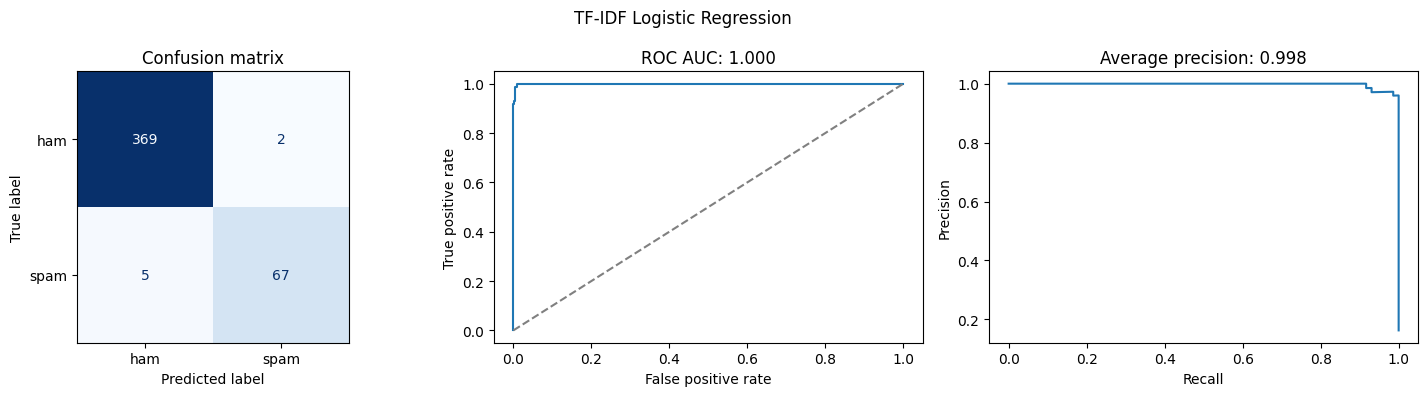

,score
accuracy,0.984199
precision,0.971014
recall,0.930556
f1,0.950355
roc_auc,0.999551
average_precision,0.997686


In [18]:
# Creating a pipeline that converts emails text into TF-IDF features and classifies them using logistic regression.
lr_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        preprocessor=normalize, stop_words=tfidf_stop_words, ngram_range=(1, 2),
        max_features=20000, min_df=2, max_df=0.98, sublinear_tf=True,
    )),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=seed)),
])

#Scoring validation emails and selecting a threshold that satisfies configured false-positive-rate limit.
lr_model.fit(train["text"], train["label"])
lr_val_scores = lr_model.predict_proba(val["text"])[:, 1]
lr_threshold = select_threshold(val["label"], lr_val_scores)

# Generating spam scores for the untouched test emails.
lr_scores = lr_model.predict_proba(test["text"])[:, 1]

# Evaluating the test predictions using the selected threshold.
lr_metrics = show_results(
    "TF-IDF Logistic Regression", test["label"].to_numpy(),
    lr_scores, lr_threshold, "classic",
)

# Saving the fitted text classification model and the selected threshold.
joblib.dump({"model": lr_model, "threshold": lr_threshold},
            model_dir / "tfidf-logistic-regression.joblib")

# Displaying the main test metrics in a compact table.             
display(pd.Series(lr_metrics).loc[["accuracy", "precision", "recall", "f1", "roc_auc", "average_precision"]].to_frame("score"))

## LSTM

Use the same stemmed normalization but retain stopwords for ordered context. Build the vocabulary from training data only, reserve tokens 0/1 for padding/unknown words, and limit each email to 300 tokens.

In [19]:
# Defining the maximum vocabulary size, maximum email length, and training batch size.
max_vocab = 20000
max_len = 300
batch_size = 64

# Cleaning emails and splitting into individual words.
def tokenize(text):
    return normalize(text).split()

# counting how often each word appears in the training emails. 
word_counts = Counter(token for text in train["text"] for token in tokenize(text))

# Reserving 0 for padding and 1 for unknown words found in the vocabulary.
vocab = {"<PAD>": 0, "<UNK>": 1}

# Adding the most common words from the training emails to the vocabulary.
vocab.update({token: index for index, (token, _) in enumerate(word_counts.most_common(max_vocab - 2), 2)})

# Convering an email into fixed length list of word numbers.
def encode_text(text):
    
    # Keeping at most 300 words and 1 for unknown words. 
    tokens = [vocab.get(token, 1) for token in tokenize(text)[:max_len]] or [1]

    # Saving the real length.
    length = len(tokens)

    # Adding zeros until every email has the same length.
    return tokens + [0] * (max_len - length), length

### Prepare the dataset

Store token IDs, the actual message lengths and labels as tensors for the data loaders.

In [20]:
# Creating a pytorch dataset that prepares emails for the LSTM.
class EmailDataset(Dataset):
    def __init__(self, frame):
        # Convert each email to tensors once, ready for the data loader.
        encoded = [encode_text(text) for text in frame["text"]]
        self.tokens = torch.tensor([item[0] for item in encoded], dtype=torch.long)
        self.lengths = torch.tensor([item[1] for item in encoded], dtype=torch.long)
        self.labels = torch.tensor(frame["label"].to_numpy(), dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):

        # Returning one encoded email, its real length, and its label.
        return self.tokens[index], self.lengths[index], self.labels[index]

### Define the model

A 128-dimensional embedding feeds a 128-unit LSTM, followed by dropout and one output logit. Prediction uses evaluation mode so dropout is disabled.

In [21]:
# Defining the LSTM model used for email classification.
class EmailLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(len(vocab), 128, padding_idx=0)
        self.lstm = nn.LSTM(128, 128, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.output = nn.Linear(128, 1)

    def forward(self, tokens, lengths):
        sequence, _ = self.lstm(self.embedding(tokens))
        rows = torch.arange(len(lengths), device=tokens.device)

        # Using the output from the final real word instead of padding.
        return self.output(self.dropout(sequence[rows, lengths - 1])).squeeze(1)

# Generating spam scores without updating the model.
def predict_lstm(model, loader, device):
    model.eval()
    probs, labels = [], []
    with torch.no_grad():
        for tokens, lengths, batch_labels in loader:
            logits = model(tokens.to(device), lengths.to(device))
            probs.extend(torch.sigmoid(logits).cpu().numpy())
            labels.extend(batch_labels.numpy())
    return np.asarray(labels, dtype=int), np.asarray(probs)

### Set up training

Run both models on the CPU. Weight spam examples by the training ham/spam ratio and optimize the binary loss with AdamW.

In [22]:
# Creating data loaders for training, validation, and testing.
generator = torch.Generator().manual_seed(seed)
train_loader = DataLoader(EmailDataset(train), batch_size=batch_size, shuffle=True, generator=generator)
val_loader = DataLoader(EmailDataset(val), batch_size=batch_size)
test_loader = DataLoader(EmailDataset(test), batch_size=batch_size)

# Running the LSTM on the CPU.
device = torch.device("cpu")
lstm_model = EmailLSTM().to(device)

# Calculating the weight should be given for spam emails
spam_weight = torch.tensor([(len(train) - train["label"].sum()) / train["label"].sum()], device=device)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=spam_weight)
optimizer = torch.optim.AdamW(lstm_model.parameters(), lr=0.001)

### Train and evaluate

Run the fixed epoch budget and restore the lowest-validation-loss checkpoint. Record both validation loss and validation F1, save the numerical history and chosen epoch, choose the final threshold on validation data, and then evaluate the test set once.

,epoch,training_loss,validation_loss,validation_f1_at_0_5
0,1,1.026361,0.837401,0.446097
1,2,0.643656,0.493453,0.794326
2,3,0.391281,0.239244,0.857143
3,4,0.237384,0.302512,0.804878
4,5,0.208255,0.375588,0.848921
5,6,0.122293,0.298545,0.884354


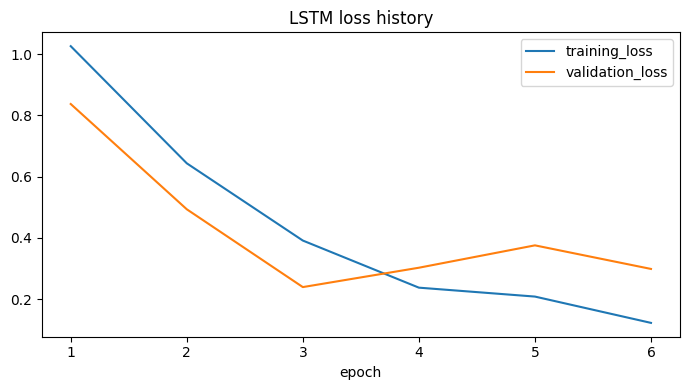

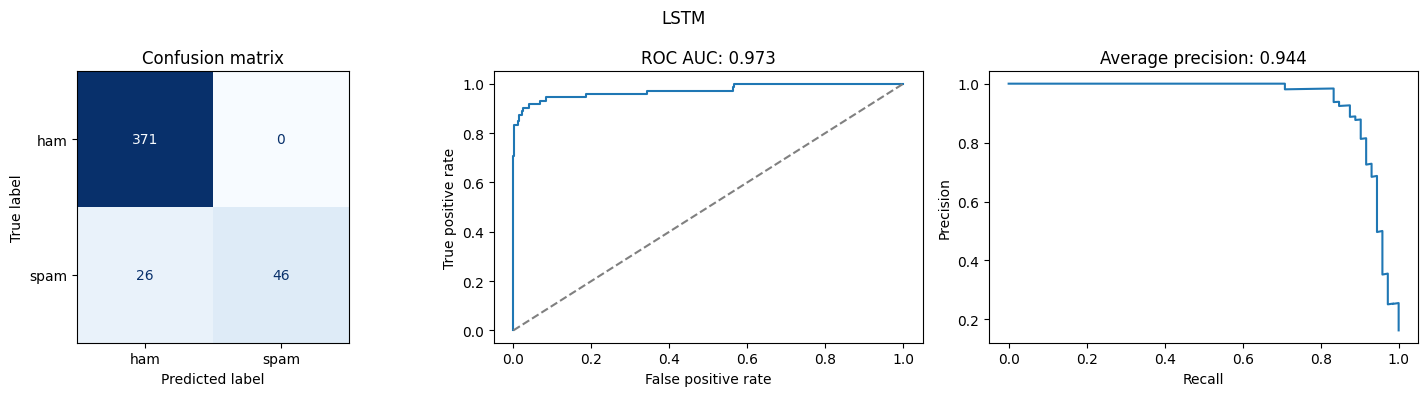

,score
accuracy,0.941309
precision,1.0
recall,0.638889
f1,0.779661
roc_auc,0.972821
average_precision,0.944358


In [23]:
# Calculating the average validation loss without changing the model.
def validation_loss(model, loader):
    model.eval()
    total = 0.0
    with torch.no_grad():
        for tokens, lengths, labels in loader:
            tokens, lengths, labels = tokens.to(device), lengths.to(device), labels.to(device)
            total += loss_fn(model(tokens, lengths), labels).item() * len(labels)
    return total / len(loader.dataset)

# Storing the training results from each cycle
history = []
best_val_loss = float("inf")

# Training the model for configured number of cycles.
for epoch in range(1, epochs + 1):
    lstm_model.train()
    total_loss = 0
    for tokens, lengths, labels in train_loader:
        tokens, lengths, labels = tokens.to(device), lengths.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = loss_fn(lstm_model(tokens, lengths), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(labels)

    # Evaluating the current model on the validation set.
    y_val, val_scores = predict_lstm(lstm_model, val_loader, device)
    val_loss = validation_loss(lstm_model, val_loader)
    val_f1 = f1_score(y_val, val_scores >= 0.5)
    history.append({"epoch": epoch, "training_loss": total_loss / len(train),
                    "validation_loss": val_loss, "validation_f1_at_0_5": val_f1})
    
    # Saving a copy of the model when validation loss improves.
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        chosen_epoch = epoch
        best_state = {name: value.detach().cpu().clone() for name, value in lstm_model.state_dict().items()}

# Restoring the weights from the cycle with the lowest validation loss.
lstm_model.load_state_dict(best_state)

# Saving the numerical training history for later reporting.
history_df = pd.DataFrame(history)
history_df.to_csv(results_dir / "metrics/lstm-training-history.csv", index=False)
display(history_df)

# Checking the training and validation loss across all cycles.
history_df.set_index("epoch")[["training_loss", "validation_loss"]].plot(figsize=(7, 4), title="LSTM loss history")
plt.tight_layout()
plt.savefig(results_dir / "figures/lstm-training-history.png", dpi=180)
plt.show()

# Using restored model to select the final threshold on validation data.
y_val, val_scores = predict_lstm(lstm_model, val_loader, device)
lstm_threshold = select_threshold(y_val, val_scores)

# Evaluating the restored model on the untouched test set.
y_test, lstm_scores = predict_lstm(lstm_model, test_loader, device)
lstm_metrics = show_results("LSTM", y_test, lstm_scores, lstm_threshold, "lstm")

# Adding training information to the saved LSTM metrics.
lstm_metrics.update({"best_validation_loss": float(best_val_loss), "chosen_epoch": chosen_epoch,
                     "epochs": epochs, "device": str(device)})
(results_dir / "metrics/lstm.json").write_text(json.dumps(lstm_metrics, indent=2))

# Saving best model weights, vocabulary, and selected threshold.
torch.save({"model_state": best_state, "vocabulary": vocab,
            "threshold": lstm_threshold}, model_dir / "lstm.pt")
# Displaying the main LSTM test metrics.
display(pd.Series(lstm_metrics).loc[["accuracy", "precision", "recall", "f1", "roc_auc", "average_precision"]].to_frame("score"))

## Compare the models

Compare both models on the same untouched test emails and save metrics, histories, manifests, models and environment details together. In Colab, download the ZIP before the runtime ends.

In [24]:
# Choosing the main metrics used to compare both models.
metric_names = ["accuracy", "precision", "recall", "f1", "roc_auc", "average_precision"]

#Putting logistic regression and LSTM mettest results into a single table.
comparison = pd.DataFrame([
    {"model": "TF-IDF Logistic Regression", **{metric: lr_metrics[metric] for metric in metric_names}},
    {"model": "LSTM", **{metric: lstm_metrics[metric] for metric in metric_names}},
])
comparison.to_csv(results_dir / "model-comparison.csv", index=False)

# Listing the main libraries used by the experiment.
packages = ["joblib", "matplotlib", "nltk", "numpy", "pandas", "scikit-learn", "torch"]
summary = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "seed": seed,
    "dataset_sha256": dataset_hashes,
    "records_after_normalized_deduplication": len(emails),
    "train_records": len(train), "validation_records": len(val), "test_records": len(test),
    "ham": int((emails["label"] == 0).sum()), "spam": int((emails["label"] == 1).sum()),
    "lstm_epochs": epochs, "lstm_chosen_epoch": chosen_epoch,
    "python": platform.python_version(),
    "platform": platform.platform(),

    # Recording the installed version of each main library.
    "packages": {name: importlib.metadata.version(name) for name in packages},
}
(results_dir / "run-summary.json").write_text(json.dumps(summary, indent=2))
display(comparison.style.format({metric: "{:.4f}" for metric in metric_names}).highlight_max(subset=metric_names, color="#d9ead3"))

# When using Colab, collect all outputs into one downloadable ZIP file.
if in_colab:
    export_dir = root / "section_01_export"
    shutil.copytree(results_dir, export_dir / "reports", dirs_exist_ok=True)
    shutil.copytree(model_dir, export_dir / "models", dirs_exist_ok=True)
    shutil.copytree(processed_dir, export_dir / "processed", dirs_exist_ok=True)
    shutil.make_archive("/content/section_01_results", "zip", root_dir=export_dir)

,model,accuracy,precision,recall,f1,roc_auc,average_precision
0,TF-IDF Logistic Regression,0.9842,0.9710,0.9306,0.9504,0.9996,0.9977
1,LSTM,0.9413,1.0000,0.6389,0.7797,0.9728,0.9444


## What to take from the results

- Compare precision, recall, F1 and the ROC/PR curves, not just accuracy. A false positive is ham flagged as spam; a false negative is missed spam.
- These historical spam/ham labels do not establish performance on modern phishing. Normalized deduplication prevents exact representation overlap, but does not prove campaign independence.
- Results are valid only after a fresh top-to-bottom run of this revision. Keep each run's exported files together and do not combine them with older saved metrics.